In [74]:
import pandas as pd 
import re
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [49]:
df = pd.read_csv("C:\\Users\\lenovo\\Desktop\\jobs_data (1).csv",encoding="cp1252")

In [50]:
print("Dataset Shape:", df.shape)

Dataset Shape: (61773, 12)


In [51]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['job_id', 'job_role', 'company', 'experience', 'salary', 'location',
       'rating', 'reviews', 'key_skills', 'posted_on', 'job_link',
       'company_link'],
      dtype='object')


In [52]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
         job_id                                           job_role    company  \
0  1.812250e+11  GN - Strategy - MC - SC&O - SC Digital Core Ar...  Accenture   
1  1.812250e+11                   GN - SC&O - BPM - Senior Manager  Accenture   
2  1.812250e+11          GN - SC&O - S&P - CLM - Associate Manager  Accenture   
3  1.812250e+11  GN - SONG - Service - Command Center of Future...  Accenture   
4  1.812250e+11                    GN - SC&O - S&P - CLM - Manager  Accenture   

  experience         salary                          location  rating  \
0    3-6 Yrs  Not disclosed     Hyderabad, Chennai, Bengaluru     3.9   
1    2-4 Yrs  Not disclosed  Gurugram, Bengaluru, Delhi / NCR     3.9   
2    1-5 Yrs  Not disclosed  Gurugram, Bengaluru, Delhi / NCR     3.9   
3  12-15 Yrs  Not disclosed    New Delhi, Gurugram, Bengaluru     3.9   
4   8-13 Yrs  Not disclosed    New Delhi, Gurugram, Bengaluru     3.9   

          reviews                                         k

In [53]:
# Basic dataset inspection
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 61773
Columns: 12


In [54]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61773 entries, 0 to 61772
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_id        61773 non-null  float64
 1   job_role      61773 non-null  object 
 2   company       41025 non-null  object 
 3   experience    60154 non-null  object 
 4   salary        61773 non-null  object 
 5   location      60663 non-null  object 
 6   rating        41029 non-null  float64
 7   reviews       41029 non-null  object 
 8   key_skills    61279 non-null  object 
 9   posted_on     61773 non-null  object 
 10  job_link      61773 non-null  object 
 11  company_link  41027 non-null  object 
dtypes: float64(2), object(10)
memory usage: 5.7+ MB


In [55]:
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing Values:
company         20748
company_link    20746
rating          20744
reviews         20744
experience       1619
location         1110
key_skills        494
job_id              0
job_role            0
salary              0
posted_on           0
job_link            0
dtype: int64


In [56]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 1185


In [57]:
# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())

def find_column(possible_names):
    for col in df.columns:
        if col in possible_names:
            return col
    return None


title_col = find_column([
    "job_title", "title", "job_role", "role"
])

company_col = find_column([
    "company", "company_name"
])

location_col = find_column([
    "location", "job_location"
])

experience_col = find_column([
    "experience", "experience_required", "exp"
])

salary_col = find_column([
    "salary", "salary_range", "pay"
])

skills_col = find_column([
    "skills", "key_skills", "required_skills"
])

rating_col = find_column([
    "company_rating", "rating"
])

posted_col = find_column([
    "posted_date", "date_posted", "posted", "posting_date"
])

job_type_col = find_column([
    "job_type", "employment_type", "type"
])

print("Job Title:", title_col)
print("Company:", company_col)
print("Location:", location_col)
print("Experience:", experience_col)
print("Salary:", salary_col)
print("Skills:", skills_col)
print("Company Rating:", rating_col)
print("Posted Date:", posted_col)


# Remove duplicate job postings
print("Rows before duplicate removal:", len(df))

duplicate_cols = [
    col for col in [title_col, company_col, location_col]
    if col is not None
]

if duplicate_cols:
    df = df.drop_duplicates(subset=duplicate_cols, keep="first")
else:
    df = df.drop_duplicates()
    
    # Clean company names
if company_col:
    df[company_col] = (
        df[company_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )



['job_id', 'job_role', 'company', 'experience', 'salary', 'location', 'rating', 'reviews', 'key_skills', 'posted_on', 'job_link', 'company_link']
Job Title: job_role
Company: company
Location: location
Experience: experience
Salary: salary
Skills: key_skills
Company Rating: rating
Posted Date: None
Rows before duplicate removal: 61773


In [58]:
# Standardize job titles

def standardize_job_title(title):
    if pd.isna(title):
        return np.nan

    title = str(title).lower().strip()

    # Data roles
    if "data scientist" in title:
        return "Data Scientist"

    elif "data analyst" in title or "business data analyst" in title:
        return "Data Analyst"

    elif "business analyst" in title:
        return "Business Analyst"

    elif "data engineer" in title:
        return "Data Engineer"

    elif "machine learning" in title or "ml engineer" in title:
        return "Machine Learning Engineer"

    elif "artificial intelligence" in title or "ai engineer" in title:
        return "AI Engineer"

     # Software roles
    elif "software engineer" in title or "software developer" in title:
        return "Software Engineer"

    elif "python developer" in title:
        return "Python Developer"

    elif "java developer" in title:
        return "Java Developer"

    elif "full stack" in title or "fullstack" in title:
        return "Full Stack Developer"

    elif "frontend" in title or "front end" in title:
        return "Frontend Developer"

    elif "backend" in title or "back end" in title:
        return "Backend Developer"

    elif "web developer" in title:
        return "Web Developer"

     # Cloud / DevOps
    elif "devops" in title:
        return "DevOps Engineer"

    elif "cloud engineer" in title:
        return "Cloud Engineer"

    # Testing
    elif "qa engineer" in title or "quality assurance" in title:
        return "QA Engineer"

    elif "test engineer" in title or "tester" in title:
        return "Test Engineer"

    # Security
    elif "cyber" in title or "security analyst" in title:
        return "Cyber Security Analyst"

    # Management
    elif "product manager" in title:
        return "Product Manager"

    elif "project manager" in title:
        return "Project Manager"

    # HR
    elif "human resource" in title or re.search(r"\bhr\b", title):
        return "HR"

    # Sales
    elif "sales" in title:
        return "Sales"

    # Marketing
    elif "marketing" in title:
        return "Marketing"

    # Otherwise clean original title
    else:
        return str(title).title()

if title_col:
    df["standardized_job_title"] = df[title_col].apply(
        standardize_job_title
    )

df[[title_col, "standardized_job_title"]].head(10)


,job_role,standardized_job_title
0,GN - Strategy - MC - SC&O - SC Digital Core Ar...,Gn - Strategy - Mc - Sc&O - Sc Digital Core Ar...
1,GN - SC&O - BPM - Senior Manager,Gn - Sc&O - Bpm - Senior Manager
2,GN - SC&O - S&P - CLM - Associate Manager,Gn - Sc&O - S&P - Clm - Associate Manager
3,GN - SONG - Service - Command Center of Future...,Gn - Song - Service - Command Center Of Future...
4,GN - SC&O - S&P - CLM - Manager,Gn - Sc&O - S&P - Clm - Manager
5,R&R FS - Python Full Stack -Manager,Full Stack Developer
6,R&R FS - Python Full Stack -Senior Associate,Full Stack Developer
7,R&R FS-Reg Reporting-Manager,R&R Fs-Reg Reporting-Manager
8,Sr Advanced Embedded Engr,Sr Advanced Embedded Engr
10,Sales Ops Specialist,Sales


In [59]:
# standardize location 
def standardize_clean_location(location):
    if pd.isna(location):
        return np.nan

    location = str(location).lower().strip()

    location = re.sub(r"\s+"," ",location)

    replacement = {
        "bangalore": "Bengaluru",
        "bengaluru": "Bengaluru",
        "gurgaon": "Gurugram",
        "gurugram": "Gurugram",
        "bombay": "Mumbai",
        "mumbai": "Mumbai",
        "delhi": "Delhi",
        "new delhi": "Delhi",
        "noida": "Noida",
        "pune": "Pune",
        "hyderabad": "Hyderabad",
        "chennai": "Chennai",
        "kolkata": "Kolkata",
        "calcutta": "Kolkata",
        "ahmedabad": "Ahmedabad",
        "jaipur": "Jaipur",
        "kochi": "Kochi",
        "cochin": "Kochi",
        "remote": "Remote",
    }

    df.head(10)

In [ ]:
# many job listing contain multiple location.
# use first location as primary location 

primary = re.split(r"[,/|;]", location[0].strip())


for key,value in replacements.item():
    if key == primary or key in primary:
        return value

return primary.title()

if location_col:
    df["standardized_location"] = df[location_col].apply(
        clean_location
    )

    df[[location_col,"standarization_location"]].head(10)

In [61]:
# convert the salary into comparable number

def salary_value_to_annual(value,text):

    text = text.lower()

    # Crore 
    if "crore" in text or "cr" in text:
        return value * 10000000

    # Lakhs / LPA
    elif (
        "lpa" in text
        or "lakh" in text 
        or "lac" in text
    ):

        return value * 100000

    # Thousands
    elif "k" in text:
        value = value * 1000 

    # Monthly salary 
    if (
        "month" in text 
        or "/month" in text
        or "monthly" in text
        or "per month" in text
    ):
        value *= 12

    # Daily salary 
    elif "day" in text or "daily" in text:
        value *= 365

    # Hourly salary 
    elif "hour" in text or "hourly" in text:
            value *= 8 * 22 * 12

    return value 

def extract_salary(salary):
    if pd.isna(salary):
          return pd.Series([np.nan,np.nan])

    salary = str(salary).lower().strip()

    # Missing/undisclosed salaries 
    missing_terms = [
        "not disclosed",
        "not specified",
        "negotiable",
        "confidential",
        "as per company",
        "as per industry",
        "na",
        "n/a"
    ]

    if any(term == salary or term in salary for term in missing_terms):
        return pd.Series([np.nan,np.nan])

    # Remove commas and ₹
    salary = salary.replace("," , "")
    salary = salary.replace("₹" , "")
    salary = salary.replace("rs." , "")
    salary = salary.replace("rs" , "")

    numbers = re.findall(r"\d+(?:\.\d+)?",salary)

    if not numbers:
        return pd.Series([np.nan,np.nan])

    numbers = [float(x) for x in numbers]

    if len(numbers) >= 2:
        min_salary = salary_value_to_annual(
            numbers[0],salary
        )

        max_salary = salary_value_to_annual(
            numbers[1],salary    
        )

    else:
        min_salary = salary_value_to_annual(
            numbers[0],salary
        )

        max_salary = min_salary

    # Remove obviously invalid values
    if min_salary < 10000:
        min_salary = np.nan

    if max_salary < 10000:
        max_salary = np.nan

    return pd.Series([min_salary,max_salary])

if  salary_col :
    df[
        ["min_salary_annual","max_salary_annual"]
    ] = df[salary_col].apply(extract_salary)

    df["avg_salary_annual"] = (
        df["min_salary_annual"]
        + df["max_salary_annual"]
    ) / 2

    # Salary in LPA for easier interpretation 
    df["min_salary_lpa"] = df["min_salary_annual"] / 100000
    df["max_salary_lpa"] = df["max_salary_annual"] / 100000
    df["avg_salary_lpa"] = df["avg_salary_annual"] / 100000

df[
    [
        salary_col,
        "min_salary_lpa",
        "max_salary_lpa",
        "avg_salary_lpa",
        
    ]
].head(20)

,salary,min_salary_lpa,max_salary_lpa,avg_salary_lpa
0,Not disclosed,NaN,NaN,NaN
1,Not disclosed,NaN,NaN,NaN
2,Not disclosed,NaN,NaN,NaN
3,Not disclosed,NaN,NaN,NaN
4,Not disclosed,NaN,NaN,NaN
5,Not disclosed,NaN,NaN,NaN
6,Not disclosed,NaN,NaN,NaN
7,Not disclosed,NaN,NaN,NaN
8,Not disclosed,NaN,NaN,NaN
10,Not disclosed,NaN,NaN,NaN


In [62]:
if salary_col:
    print(df["avg_salary_lpa"].describe())

count    17506.000000
mean       989.616443
std       5436.545082
min          0.250000
25%          3.000000
50%          4.500000
75%         10.000000
max      48001.500000
Name: avg_salary_lpa, dtype: float64


In [63]:
df["salary_valid"] = df["avg_salary_lpa"].where(
    (df["avg_salary_lpa"] >= 0.5)
    & (df["avg_salary_lpa"] <= 100)
)

In [64]:
def clean_skills(skills):
    if pd.isna(skills):
        return[]

    skills = str(skills).lower()

    # Normalize separators
    skills = re.sub(r"[|;/]",",",skills)

    skill_list = [
        skill.strip()
        for skill in skills.split(",")
        if skill.strip()
    ]

    return skill_list

if skills_col:
    df["skills_list"] = df[skills_col].apply(clean_skills)

df[[skills_col,"skills_list"]].head(10)
        

,key_skills,skills_list
0,"sap ariba,presentation skills,solution impleme...","[sap ariba, presentation skills, solution impl..."
1,"spend analysis,market research,sales and opera...","[spend analysis, market research, sales and op..."
2,"Sourcing,PowerBI,procurement,digital sourcing,...","[sourcing, powerbi, procurement, digital sourc..."
3,"cloud solutions,WFM solutions,AI,Customer Enga...","[cloud solutions, wfm solutions, ai, customer ..."
4,"Procurement,Sourcing,Supply Chain Management,p...","[procurement, sourcing, supply chain managemen..."
5,"Data analysis,Data management,Analytical,Consu...","[data analysis, data management, analytical, c..."
6,"Data analysis,Automation,Analytical,Consulting...","[data analysis, automation, analytical, consul..."
7,"Data analysis,Automation,Data management,Busin...","[data analysis, automation, data management, b..."
8,"RTOS,Test case execution,C++,Linux,Programming...","[rtos, test case execution, c++, linux, progra..."
10,"Computer science,Team management,Analytical,Sa...","[computer science, team management, analytical..."


In [65]:
skill_mapping = {
    "python": "Python",
    "python programming": "Python",

    "sql": "SQL",
    "mysql": "mySQL",
    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",

    "ms excel": "Excel",
    "microsoft excel": "Excel",
    "advanced excel": "Excel",
    "excel": "Excel",

    "powerbi": "Power BI",
    "power bi": "Power BI",

    "tableau": "Tableau",

    "machine learning": "Machine Learning",
    "ml": "Machine Learning",

    "deep learning": "Deep Learning",

    "artificial intelligence": "Artificial intelligence",
    "ai": "Artificial intelligence",

    "amazon web services": "AWS",
    "aws": "AWS",

    "microsoft azure": "Azure",
    "azure": "Azure",

    "google cloud platform": "GCP",
    "gcp": "GCP",

    "javascript": "JavaScript",
    "java script": "JavaScript",

    "reactjs": "React",
    "react.js": "React",
    "react": "React",

    "nodejs": "Node.js",
    "node.js": "Node.js",

    "c++": "C++",
    "c#": "C#",

    "html": "HTML",
    "css": "CSS",

    "spark": "Apache Spark",
    "apache spark": "Apache Spark",

    "docker": "Docker",
    "kubernetes": "Kubernetes",

    "git": "Git"
}

def standardize_skill(skill):

    skill = skill.lower().strip()

    if skill in skill_mapping:
        return skill_mapping[skill]

    return skill.title()

if skills_col:
    df["skills_list"] = df["skills_list"].apply(
        lambda x: list(dict.fromkeys(
            standardize_skill(skill)
            for skill in x
        ))
    )

In [66]:
if posted_col:

    df[posted_col] = pd.to_datetime(
        df[posted_col],
        errors="coerce"
    )

    df["posted_year"] = df[posted_col].dt.year
    df["posted_month"] = df[posted_col].dt.month
    df["posted_month_name"] = df[posted_col].dt.month_name()

    print(df[posted_col].head())

In [67]:
if rating_col:

    df[rating_col] = pd.to_numeric(
        df[rating_col],
        errors="coerce"
    )

    # Keep standard 0-5 ratings 
    df.loc[
        ~df[rating_col].between(0,5),
        rating_col
    ] = np.nan

    print(df[rating_col].describe())

count    34067.000000
mean         3.793718
std          0.547990
min          1.000000
25%          3.500000
50%          3.900000
75%          4.100000
max          5.000000
Name: rating, dtype: float64


In [68]:
print("Final dataset shape:",df.shape)

df.head()

Final dataset shape: (53169, 21)


,job_id,job_role,company,experience,salary,location,rating,reviews,key_skills,posted_on,...,company_link,standardized_job_title,min_salary_annual,max_salary_annual,avg_salary_annual,min_salary_lpa,max_salary_lpa,avg_salary_lpa,salary_valid,skills_list
0,1.812250e+11,GN - Strategy - MC - SC&O - SC Digital Core Ar...,Accenture,3-6 Yrs,Not disclosed,"Hyderabad, Chennai, Bengaluru",3.9,52479 Reviews,"sap ariba,presentation skills,solution impleme...",1 Day Ago,...,https://www.naukri.com/accenture-jobs-careers-...,Gn - Strategy - Mc - Sc&O - Sc Digital Core Ar...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Sap Ariba, Presentation Skills, Solution Impl..."
1,1.812250e+11,GN - SC&O - BPM - Senior Manager,Accenture,2-4 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / NCR",3.9,52479 Reviews,"spend analysis,market research,sales and opera...",1 Day Ago,...,https://www.naukri.com/accenture-jobs-careers-...,Gn - Sc&O - Bpm - Senior Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Spend Analysis, Market Research, Sales And Op..."
2,1.812250e+11,GN - SC&O - S&P - CLM - Associate Manager,Accenture,1-5 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / NCR",3.9,52479 Reviews,"Sourcing,PowerBI,procurement,digital sourcing,...",1 Day Ago,...,https://www.naukri.com/accenture-jobs-careers-...,Gn - Sc&O - S&P - Clm - Associate Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Sourcing, Power BI, Procurement, Digital Sour..."
3,1.812250e+11,GN - SONG - Service - Command Center of Future...,Accenture,12-15 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"cloud solutions,WFM solutions,AI,Customer Enga...",1 Day Ago,...,https://www.naukri.com/accenture-jobs-careers-...,Gn - Song - Service - Command Center Of Future...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Cloud Solutions, Wfm Solutions, Artificial in..."
4,1.812250e+11,GN - SC&O - S&P - CLM - Manager,Accenture,8-13 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"Procurement,Sourcing,Supply Chain Management,p...",1 Day Ago,...,https://www.naukri.com/accenture-jobs-careers-...,Gn - Sc&O - S&P - Clm - Manager,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[Procurement, Sourcing, Supply Chain Managemen..."


In [69]:
df.to_csv(
    "cleaned_job_market_dataset.csv",
    index=False
)

print("Cleaned dataset saved")

Cleaned dataset saved


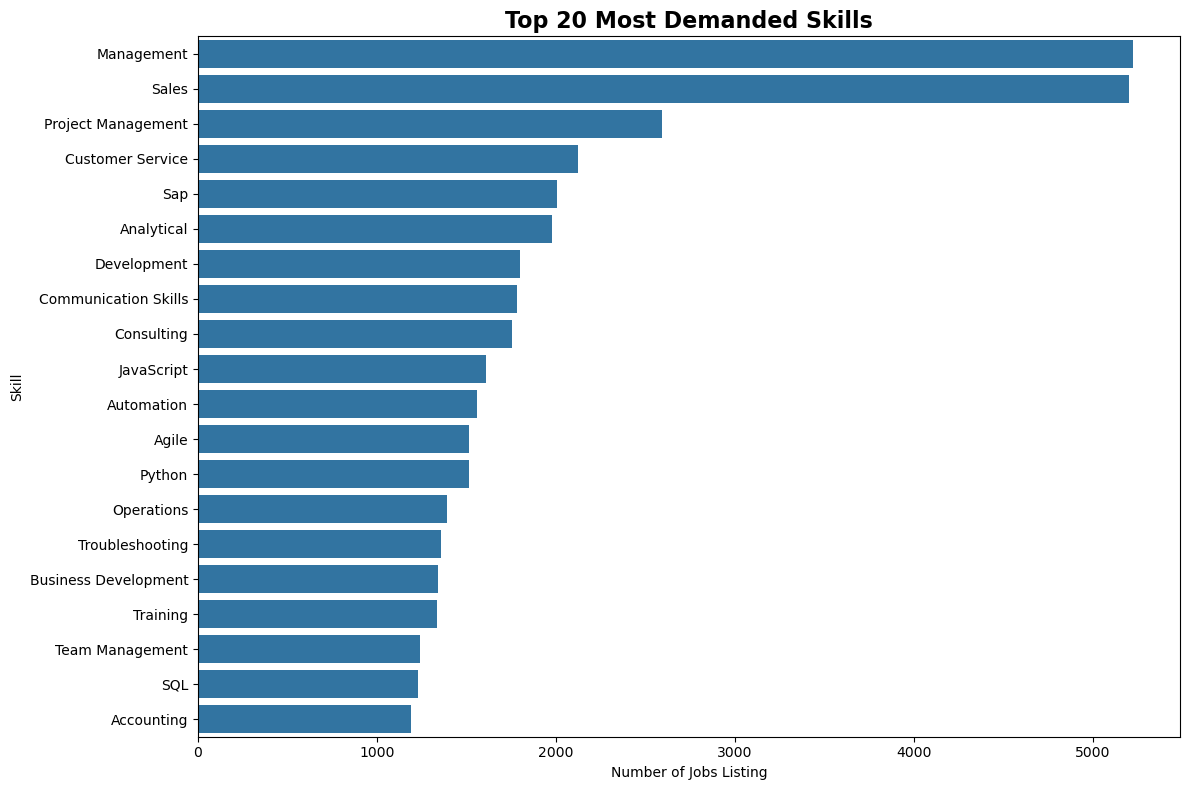

Top 10 Most Demanded Skills
                  skill  Job_Count
0            Management       5226
1                 Sales       5202
2    Project Management       2592
3      Customer Service       2126
4                   Sap       2004
5            Analytical       1976
6           Development       1799
7  Communication Skills       1782
8            Consulting       1755
9            JavaScript       1609


In [76]:
skills_df = df[
    ["skills_list"]
].explode("skills_list")

skills_df = skills_df.dropna()

skill_counts = (
    skills_df["skills_list"]
    .value_counts()
    .reset_index()
)

skill_counts.columns = ["skill", "Job_Count"]

skill_counts.head(20)

top_skills = skill_counts.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_skills,
    x="Job_Count",
    y="skill"
)

plt.title(
    "Top 20 Most Demanded Skills",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Jobs Listing")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

print("Top 10 Most Demanded Skills")
print(skill_counts.head(10))

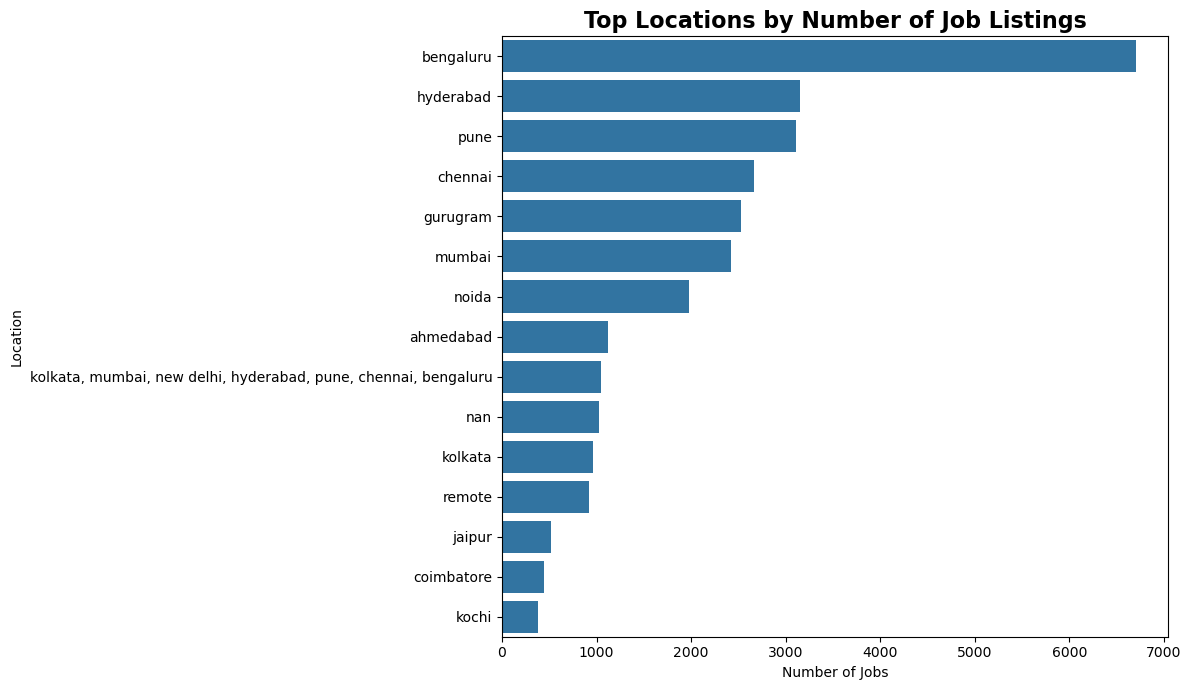

In [86]:
# Create standardized location column
df["standardized_location"] = (
    df["location"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Count job listings by location
location_counts = (
    df["standardized_location"]
    .value_counts()
    .reset_index()
)

location_counts.columns = [
    "Location",
    "Job_Count"
]

# Select top 15 locations
top_locations = location_counts.head(15)

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_locations,
    x="Job_Count",
    y="Location"
)

plt.title(
    "Top Locations by Number of Job Listings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Jobs")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

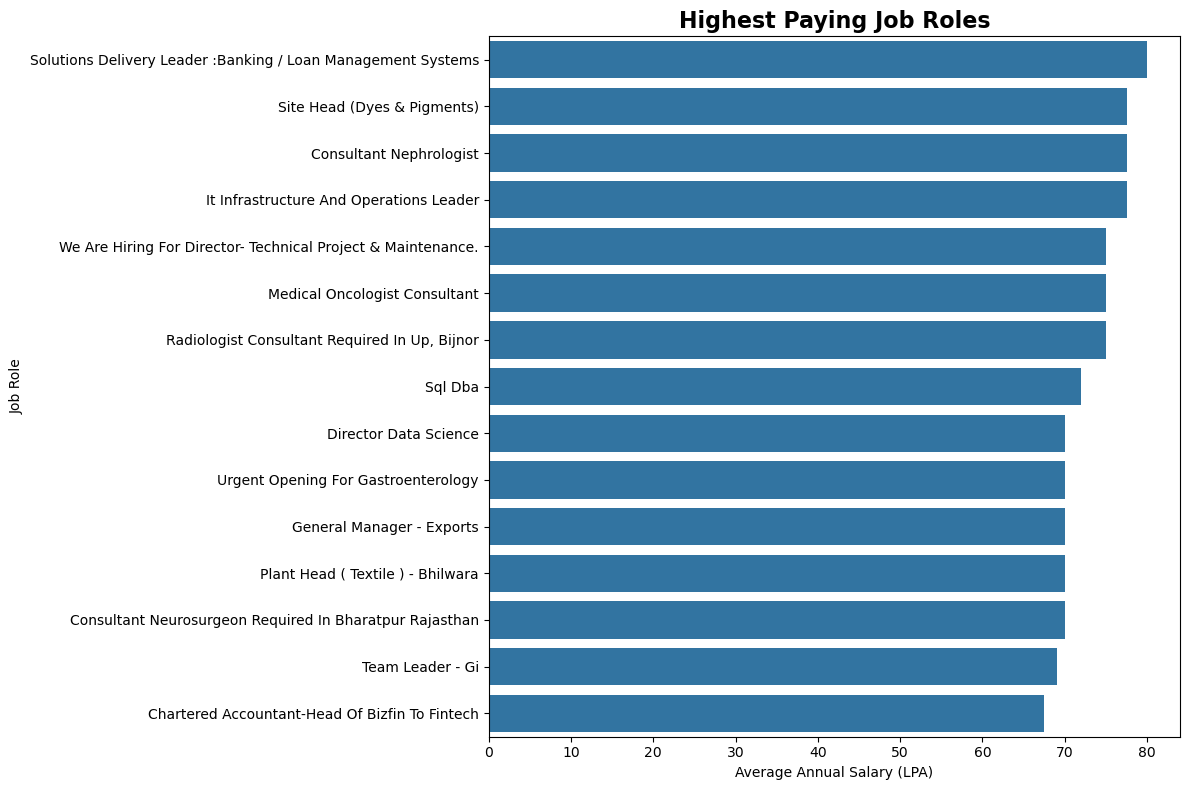

In [87]:
# Remove rows with missing job title or salary
salary_role_df = df.dropna(
    subset=[
        "standardized_job_title",
        "salary_valid"
    ]
)

# Calculate salary statistics for each job role
role_salary = (
    salary_role_df
    .groupby("standardized_job_title")
    .agg(
        Average_Salary_LPA=("salary_valid", "mean"),
        Median_Salary_LPA=("salary_valid", "median"),
        Job_Count=("salary_valid", "count")
    )
    .reset_index()
)

# Sort by average salary and select top 15 roles
top_salary_roles = (
    role_salary
    .sort_values(
        by="Average_Salary_LPA",
        ascending=False
    )
    .head(15)
)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_salary_roles,
    x="Average_Salary_LPA",
    y="standardized_job_title"
)

plt.title(
    "Highest Paying Job Roles",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Annual Salary (LPA)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

                      avg_experience_years  salary_valid
avg_experience_years                   NaN           NaN
salary_valid                           NaN           NaN


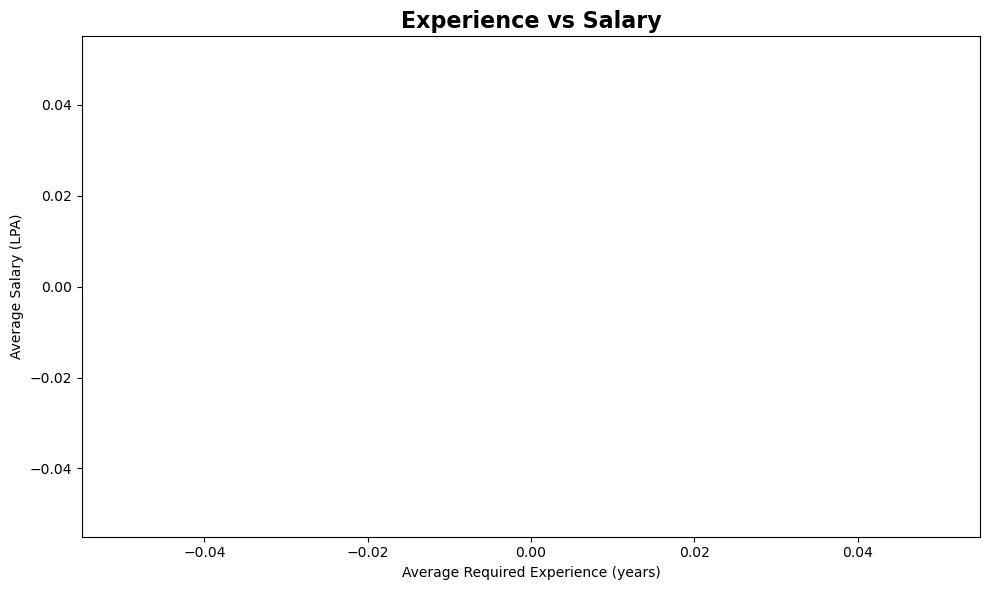

In [92]:
# Convert experience to numeric
df["avg_experience_years"] = pd.to_numeric(
    df["experience"],
    errors="coerce"
)

# Remove missing values
exp_salary_df = df.dropna(
    subset=[
        "avg_experience_years",
        "salary_valid"
    ]
).copy()

# Correlation
print(
    exp_salary_df[
        ["avg_experience_years", "salary_valid"]
    ].corr()
)

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=exp_salary_df,
    x="avg_experience_years",
    y="salary_valid",
    alpha=0.4
)

plt.title(
    "Experience vs Salary",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Required Experience (years)")
plt.ylabel("Average Salary (LPA)")

plt.tight_layout()
plt.show()


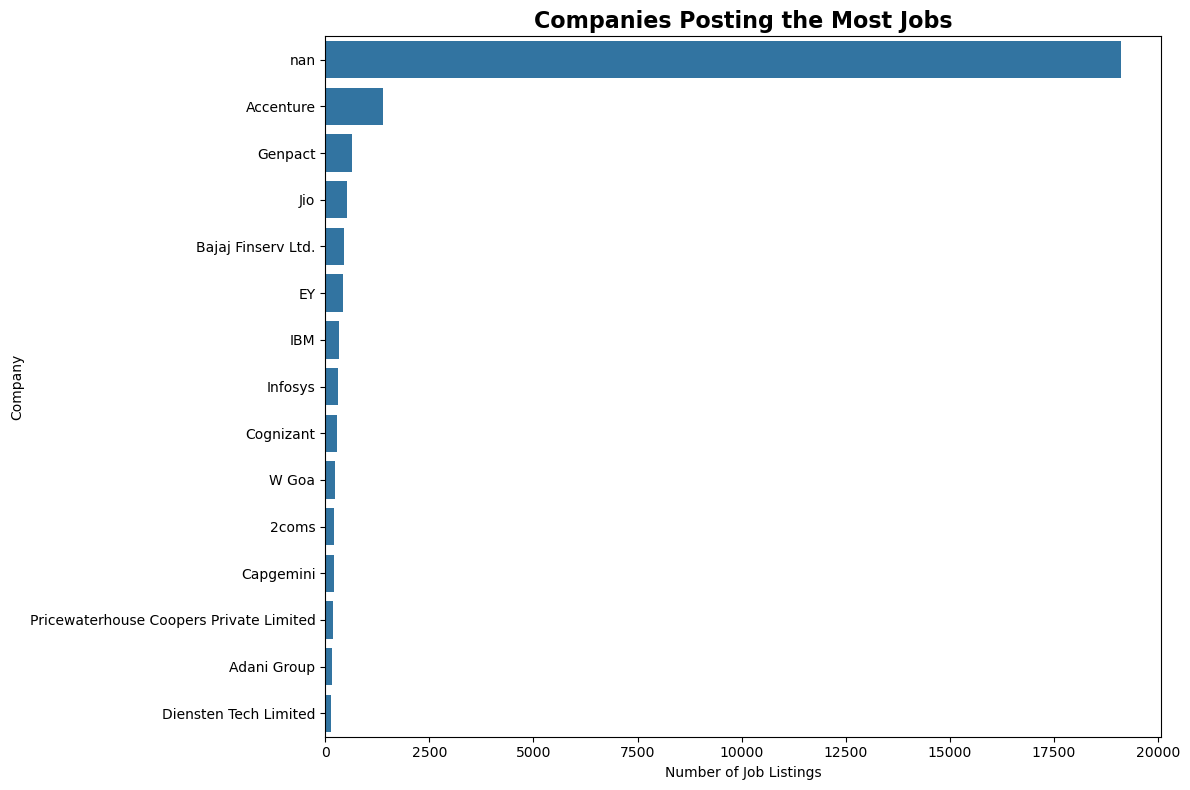

In [93]:
# Count job listings by company
company_counts = (
    df["company"]
    .dropna()
    .value_counts()
    .reset_index()
)

# Rename columns
company_counts.columns = [
    "Company",
    "Job_Count"
]

# Select top 15 companies
top_companies = company_counts.head(15)

# Plot
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_companies,
    x="Job_Count",
    y="Company"
)

plt.title(
    "Companies Posting the Most Jobs",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Job Listings")
plt.ylabel("Company")

plt.tight_layout()
plt.show()
